# JOSS Paper Figures

This notebook generates the two figures for the HyPlan JOSS paper.

| Figure | Description | Data sources |
|--------|-------------|--------------|
| Fig 1 | Flat-earth vs terrain-aware flight planning | Copernicus GLO-30 DEM |
| Fig 2 | Complete mission — still air vs wind | Airport database |

**Outputs:** Each figure is saved as both PNG (300 dpi) and PDF in this directory.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LightSource
import geopandas as gpd
import rasterio
from shapely.ops import unary_union

from hyplan import (
    AVIRIS3, KingAirB200,
    Airport, initialize_data,
    box_around_polygon, box_around_polygon_terrain,
    compute_flight_plan, ConstantWindField,
    generate_swath_polygon, calculate_swath_widths,
    ureg,
)
from hyplan.terrain import generate_demfile

# Output directory (same directory as this notebook)
FIG_DIR = os.path.abspath(".")

%matplotlib inline

## Figure 1: Flat-Earth vs Terrain-Aware Flight Planning

Side-by-side comparison over Rincón de la Vieja National Park, Costa Rica
(elevation 234–2,072 m). The flat-earth approach assumes uniform swath
width and produces fewer, evenly spaced lines. The terrain-aware approach
uses ray–terrain intersection to measure actual swath width at each line
position, revealing that terrain narrows the swath over ridges and
requires additional lines to maintain coverage.

- **(a)** Flat-earth: uniform line spacing, swath polygons ignore terrain
- **(b)** Terrain-aware: variable line spacing, swath polygons account for terrain
- **(c)** Coverage difference: gaps in the flat-earth plan revealed by terrain

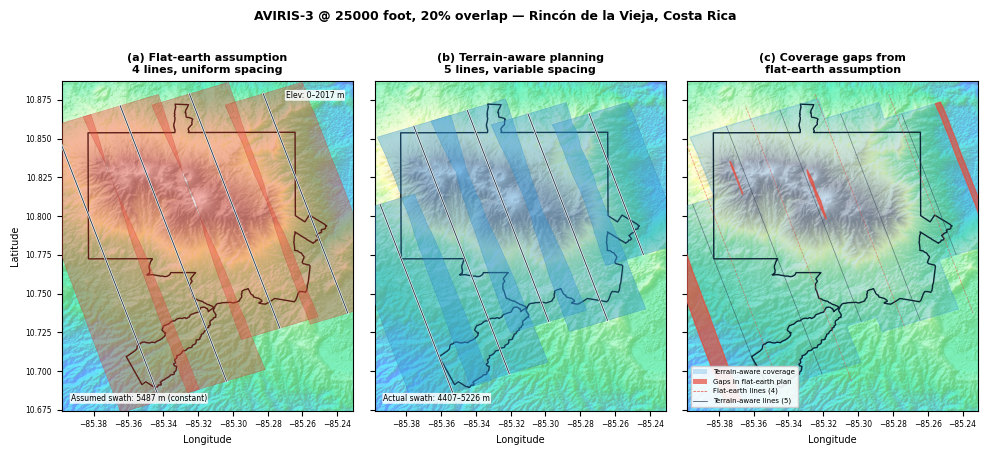

Figure 1 saved. Flat-earth: 4 lines, Terrain-aware: 5 lines.


In [2]:
sensor = AVIRIS3()
flight_altitude = ureg.Quantity(25000, "feet")

# Rincón de la Vieja National Park, Costa Rica
gdf = gpd.read_file(os.path.join(FIG_DIR, "rincon_de_la_vieja.geojson"))
study_area = gdf.geometry.iloc[0]
centroid = study_area.centroid
bounds = study_area.bounds

# DEM
dem_file = generate_demfile(
    np.array([bounds[1], bounds[3]]),
    np.array([bounds[0], bounds[2]]),
)

# Clipping polygon (buffered to ensure full swath coverage at edges)
clip_buffer_deg = 0.012
buffered_area = study_area.buffer(clip_buffer_deg)

# ── Flat-earth flight lines ──
lines_flat = box_around_polygon(
    instrument=sensor,
    altitude_msl=flight_altitude,
    polygon=study_area,
    box_name="RDV",
    overlap=20.0,
    alternate_direction=True,
    clip_to_polygon=True,
)

# ── Terrain-aware flight lines ──
lines_terrain = box_around_polygon_terrain(
    instrument=sensor,
    altitude_msl=flight_altitude,
    polygon=study_area,
    box_name="RDV",
    overlap=20.0,
    alternate_direction=True,
    clip_to_polygon=True,
    clip_polygon=buffered_area,
)

# ── Swath polygons ──
# Flat-earth swaths (no DEM)
swaths_flat = []
for fl in lines_flat:
    try:
        sw = generate_swath_polygon(fl, sensor, along_precision=500.0)
        swaths_flat.append(sw)
    except Exception:
        swaths_flat.append(None)

# Terrain-aware swaths (with DEM)
swaths_terrain = []
for fl in lines_terrain:
    try:
        sw = generate_swath_polygon(fl, sensor, along_precision=500.0, dem_file=dem_file)
        swaths_terrain.append(sw)
    except Exception:
        swaths_terrain.append(None)

# Flat-earth swaths projected onto actual terrain (to reveal gaps)
swaths_flat_on_terrain = []
for fl in lines_flat:
    try:
        sw = generate_swath_polygon(fl, sensor, along_precision=500.0, dem_file=dem_file)
        swaths_flat_on_terrain.append(sw)
    except Exception:
        swaths_flat_on_terrain.append(None)

# ── DEM shaded relief ──
with rasterio.open(dem_file) as src:
    dem_data = src.read(1)
    dem_bounds = src.bounds
    valid = dem_data[dem_data > 0]
    elev_min, elev_max = int(valid.min()), int(valid.max())

ls = LightSource(azdeg=315, altdeg=35)
rgb = ls.shade(dem_data, cmap=plt.cm.terrain, vert_exag=2, blend_mode="soft")
fade = 0.4
rgb[..., :3] = rgb[..., :3] * (1 - fade) + fade
dem_extent = [dem_bounds.left, dem_bounds.right, dem_bounds.bottom, dem_bounds.top]

# ── Swath width statistics ──
flat_widths = [calculate_swath_widths(sw) for sw in swaths_flat if sw is not None and sw.is_valid]
terrain_widths = [calculate_swath_widths(sw) for sw in swaths_terrain if sw is not None and sw.is_valid]
flat_on_terrain_widths = [calculate_swath_widths(sw) for sw in swaths_flat_on_terrain if sw is not None and sw.is_valid]

# Coverage analysis
valid_flat_terrain = [sw for sw in swaths_flat_on_terrain if sw is not None and sw.is_valid]
valid_terrain = [sw for sw in swaths_terrain if sw is not None and sw.is_valid]

union_flat = unary_union(valid_flat_terrain) if valid_flat_terrain else None
union_terrain = unary_union(valid_terrain) if valid_terrain else None

# ── Figure: 3 panels ──
fig, (ax_a, ax_b, ax_c) = plt.subplots(1, 3, figsize=(10, 4.5), sharex=True, sharey=True)

pad = 0.015
xlim = (bounds[0] - pad, bounds[2] + pad)
ylim = (bounds[1] - pad, bounds[3] + pad)

ann_bbox = dict(boxstyle="round,pad=0.12", facecolor="white",
                edgecolor="none", alpha=0.85)

sx, sy = study_area.exterior.xy

for ax in (ax_a, ax_b, ax_c):
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect("equal")
    ax.tick_params(labelsize=5.5)
    ax.imshow(rgb, extent=dem_extent, origin="upper", aspect="auto", zorder=0)
    ax.plot(sx, sy, color="black", linewidth=1, zorder=2)

# ── Panel (a): Flat-earth ──
for sw in swaths_flat:
    if sw is not None and sw.is_valid:
        swx, swy = sw.exterior.xy
        ax_a.fill(swx, swy, alpha=0.4, color="#e74c3c", edgecolor="#c0392b",
                  linewidth=0.4, zorder=3)

for fl in lines_flat:
    x = [fl.waypoint1.longitude, fl.waypoint2.longitude]
    y = [fl.waypoint1.latitude, fl.waypoint2.latitude]
    ax_a.plot(x, y, color="white", linewidth=1.5, zorder=4)
    ax_a.plot(x, y, color="#2c3e50", linewidth=0.7, zorder=5)

ax_a.set_title(f"(a) Flat-earth assumption\n{len(lines_flat)} lines, uniform spacing",
               fontsize=8, fontweight="bold")
ax_a.set_ylabel("Latitude", fontsize=7)
ax_a.set_xlabel("Longitude", fontsize=7)

if flat_widths:
    sw_flat = sensor.swath_width(flight_altitude).to(ureg.meter).magnitude
    ax_a.text(0.03, 0.03, f"Assumed swath: {sw_flat:.0f} m (constant)",
              transform=ax_a.transAxes, fontsize=5.5,
              bbox=ann_bbox, zorder=6)

# ── Panel (b): Terrain-aware ──
for sw in swaths_terrain:
    if sw is not None and sw.is_valid:
        swx, swy = sw.exterior.xy
        ax_b.fill(swx, swy, alpha=0.4, color="#3498db", edgecolor="#2980b9",
                  linewidth=0.4, zorder=3)

for fl in lines_terrain:
    x = [fl.waypoint1.longitude, fl.waypoint2.longitude]
    y = [fl.waypoint1.latitude, fl.waypoint2.latitude]
    ax_b.plot(x, y, color="white", linewidth=1.5, zorder=4)
    ax_b.plot(x, y, color="#2c3e50", linewidth=0.7, zorder=5)

ax_b.set_title(f"(b) Terrain-aware planning\n{len(lines_terrain)} lines, variable spacing",
               fontsize=8, fontweight="bold")
ax_b.set_xlabel("Longitude", fontsize=7)

if terrain_widths:
    w_min = min(w["min_width"] for w in terrain_widths)
    w_max = max(w["max_width"] for w in terrain_widths)
    ax_b.text(0.03, 0.03, f"Actual swath: {w_min:.0f}\u2013{w_max:.0f} m",
              transform=ax_b.transAxes, fontsize=5.5,
              bbox=ann_bbox, zorder=6)

# ── Panel (c): Coverage gaps ──
# Show terrain-aware coverage in blue (good)
if union_terrain is not None:
    if union_terrain.geom_type == "MultiPolygon":
        for g in union_terrain.geoms:
            gx, gy = g.exterior.xy
            ax_c.fill(gx, gy, alpha=0.25, color="#3498db", zorder=3)
    else:
        gx, gy = union_terrain.exterior.xy
        ax_c.fill(gx, gy, alpha=0.25, color="#3498db", zorder=3)

# Show gaps: area covered by terrain-aware but missed by flat-earth
if union_flat is not None and union_terrain is not None:
    gaps = union_terrain.difference(union_flat)
    if not gaps.is_empty:
        polys = gaps.geoms if gaps.geom_type == "MultiPolygon" else [gaps]
        for g in polys:
            if g.geom_type == "Polygon":
                gx, gy = g.exterior.xy
                ax_c.fill(gx, gy, alpha=0.7, color="#e74c3c", zorder=4)
        ax_c.fill([], [], alpha=0.7, color="#e74c3c", label="Gaps in flat-earth plan")

# Show flight lines from both
for fl in lines_flat:
    x = [fl.waypoint1.longitude, fl.waypoint2.longitude]
    y = [fl.waypoint1.latitude, fl.waypoint2.latitude]
    ax_c.plot(x, y, color="#e74c3c", linewidth=0.5, linestyle="--", alpha=0.6, zorder=5)

for fl in lines_terrain:
    x = [fl.waypoint1.longitude, fl.waypoint2.longitude]
    y = [fl.waypoint1.latitude, fl.waypoint2.latitude]
    ax_c.plot(x, y, color="#2c3e50", linewidth=0.5, alpha=0.6, zorder=5)

ax_c.set_title("(c) Coverage gaps from\nflat-earth assumption",
               fontsize=8, fontweight="bold")
ax_c.set_xlabel("Longitude", fontsize=7)

legend_elements = [
    mpatches.Patch(facecolor="#3498db", alpha=0.25, label="Terrain-aware coverage"),
    mpatches.Patch(facecolor="#e74c3c", alpha=0.7, label="Gaps in flat-earth plan"),
    plt.Line2D([0], [0], color="#e74c3c", lw=0.5, ls="--", label=f"Flat-earth lines ({len(lines_flat)})"),
    plt.Line2D([0], [0], color="#2c3e50", lw=0.5, label=f"Terrain-aware lines ({len(lines_terrain)})"),
]
ax_c.legend(handles=legend_elements, loc="lower left", fontsize=5, framealpha=0.9)

# Elevation annotation on panel (a)
ax_a.text(0.97, 0.97, f"Elev: {elev_min}\u2013{elev_max} m",
          transform=ax_a.transAxes, fontsize=5.5, ha="right", va="top",
          bbox=ann_bbox, zorder=6)

fig.suptitle(
    f"AVIRIS-3 @ {flight_altitude.to(ureg.feet):.0f}, 20% overlap "
    f"\u2014 Rinc\u00f3n de la Vieja, Costa Rica",
    fontsize=9, fontweight="bold", y=1.0)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig1_terrain_comparison.png"), dpi=300,
            bbox_inches="tight", facecolor="white")
fig.savefig(os.path.join(FIG_DIR, "fig1_terrain_comparison.pdf"),
            bbox_inches="tight", facecolor="white")
plt.show()
print(f"Figure 1 saved. Flat-earth: {len(lines_flat)} lines, Terrain-aware: {len(lines_terrain)} lines.")

## Figure 2: Complete Mission — Still Air vs Wind

Uses `compute_flight_plan` over Rincón de la Vieja with MRLB (Liberia)
as the departure/return airport. Compares still-air Dubins transit arcs
against trochoidal arcs in 60 kt northeasterly wind.

- **Top row:** Map views (still air vs wind)
- **Bottom:** Altitude profile overlay

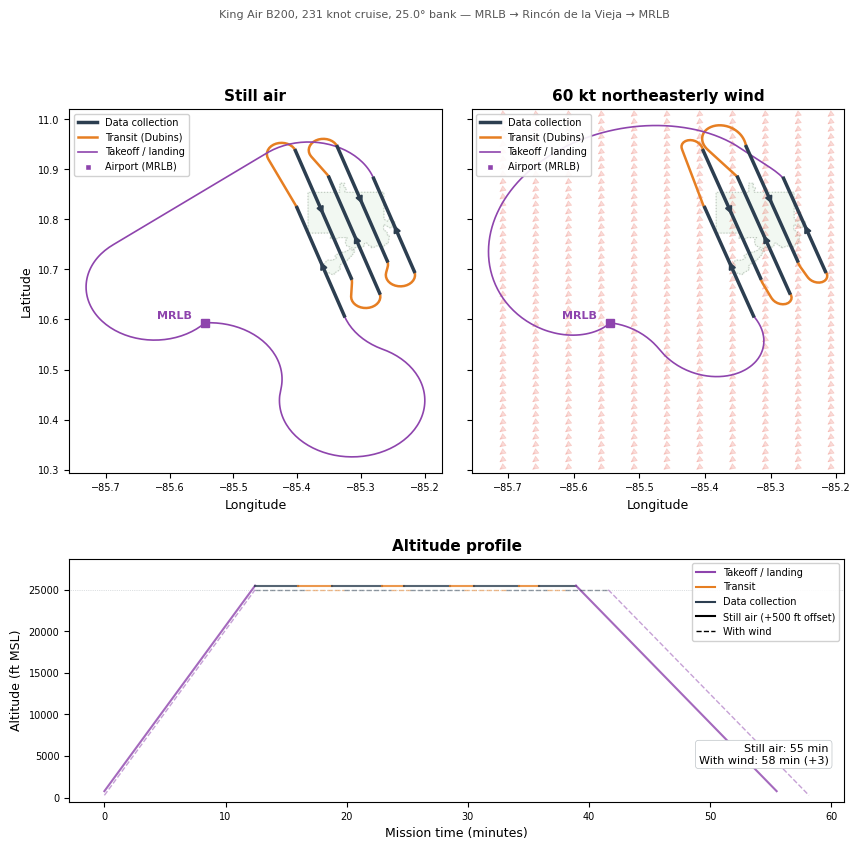

Figure 2 saved.


In [3]:
sensor = AVIRIS3()
aircraft = KingAirB200()
flight_altitude = ureg.Quantity(25000, "feet")
cruise_speed = aircraft.cruise_speed_at(flight_altitude)
bank_angle = 25.0

gdf = gpd.read_file(os.path.join(FIG_DIR, "rincon_de_la_vieja.geojson"))
study_area = gdf.geometry.iloc[0]

initialize_data(countries=["CR"])
airport = Airport("MRLB")

# Terrain-aware clipped lines (same parameters as Figure 1)
clip_buffer_deg = 0.012
buffered_area = study_area.buffer(clip_buffer_deg)

lines = box_around_polygon_terrain(
    instrument=sensor,
    altitude_msl=flight_altitude,
    polygon=study_area,
    box_name="RDV",
    overlap=20.0,
    alternate_direction=True,
    clip_to_polygon=True,
    clip_polygon=buffered_area,
)

# Wind: 60 kt northeasterly (from NE)
wind_speed = 60 * ureg.knot
wind_field = ConstantWindField(wind_speed=wind_speed, wind_from_deg=45.0)

# Flight plans
plan_still = compute_flight_plan(
    aircraft=aircraft, flight_sequence=lines,
    takeoff_airport=airport, return_airport=airport,
)
plan_wind = compute_flight_plan(
    aircraft=aircraft, flight_sequence=lines,
    takeoff_airport=airport, return_airport=airport,
    wind_source=wind_field,
)

# Segment colors
seg_colors = {
    "takeoff": "#8e44ad", "climb": "#8e44ad",
    "transit": "#e67e22",
    "flight_line": "#2c3e50",
    "descent": "#8e44ad", "approach": "#8e44ad",
}
seg_lw = {
    "takeoff": 1.2, "climb": 1.2,
    "transit": 1.8,
    "flight_line": 2.5,
    "descent": 1.2, "approach": 1.2,
}

# Figure
fig = plt.figure(figsize=(10, 9))
gs = fig.add_gridspec(2, 2, height_ratios=[1.2, 0.8], hspace=0.28, wspace=0.08)
ax_map1 = fig.add_subplot(gs[0, 0])
ax_map2 = fig.add_subplot(gs[0, 1], sharey=ax_map1)
ax_alt = fig.add_subplot(gs[1, :])

# Top row: Map views
for ax, plan, title in [
    (ax_map1, plan_still, "Still air"),
    (ax_map2, plan_wind, "60 kt northeasterly wind"),
]:
    sx, sy = study_area.exterior.xy
    ax.plot(sx, sy, color="gray", linewidth=0.8, linestyle=":", alpha=0.4, zorder=1)
    ax.fill(sx, sy, alpha=0.05, color="green", zorder=0)

    ax.plot(airport.longitude, airport.latitude, "s", color="#8e44ad",
            markersize=6, zorder=6)
    ax.text(airport.longitude - 0.02, airport.latitude + 0.008,
            airport.icao_code, fontsize=8, color="#8e44ad",
            fontweight="bold", zorder=6, ha="right")

    for _, seg in plan.iterrows():
        geom = seg.geometry
        if geom is None or geom.is_empty:
            continue
        seg_type = seg["segment_type"]
        color = seg_colors.get(seg_type, "#bdc3c7")
        lw = seg_lw.get(seg_type, 1.0)
        xs, ys = geom.xy
        ax.plot(xs, ys, color=color, linewidth=lw,
                zorder=3 if seg_type == "flight_line" else 2)

        if seg_type == "flight_line":
            mid = len(xs) // 2
            if mid > 0:
                ax.annotate("", xy=(xs[mid], ys[mid]),
                            xytext=(xs[mid - 1], ys[mid - 1]),
                            arrowprops=dict(arrowstyle="-|>", color=color, lw=1.5),
                            zorder=5)

    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Longitude", fontsize=9)
    ax.tick_params(labelsize=7)

    # Wind arrows (right panel only)
    if plan is plan_wind:
        xlims = ax.get_xlim()
        ylims = ax.get_ylim()
        for wlon in np.arange(xlims[0], xlims[1], 0.05):
            for wlat in np.arange(ylims[0], ylims[1], 0.015):
                ax.annotate("", xy=(wlon - 0.011, wlat - 0.011),
                            xytext=(wlon, wlat),
                            arrowprops=dict(arrowstyle="-|>", color="#e74c3c",
                                            lw=0.5, alpha=0.2), zorder=1)

ax_map1.set_ylabel("Latitude", fontsize=9)
plt.setp(ax_map2.get_yticklabels(), visible=False)

legend_elements = [
    plt.Line2D([0], [0], color="#2c3e50", linewidth=2.5, label="Data collection"),
    plt.Line2D([0], [0], color="#e67e22", linewidth=1.8, label="Transit (Dubins)"),
    plt.Line2D([0], [0], color="#8e44ad", linewidth=1.2, label="Takeoff / landing"),
    plt.Line2D([0], [0], marker="s", color="w", markerfacecolor="#8e44ad",
               markersize=5, label=f"Airport ({airport.icao_code})"),
]
ax_map1.legend(handles=legend_elements, loc="upper left", fontsize=7, framealpha=0.9)
ax_map2.legend(handles=legend_elements, loc="upper left", fontsize=7, framealpha=0.9)

# Bottom: Altitude profile
alt_offset = 500
for plan, label, ls, alpha, offset in [
    (plan_still, "Still air", "-", 0.8, alt_offset),
    (plan_wind, "With wind", "--", 0.5, 0),
]:
    cum_time = 0.0
    for _, seg in plan.iterrows():
        t = seg["time_to_segment"]
        seg_type = seg["segment_type"]
        color = seg_colors.get(seg_type, "#bdc3c7")
        h_start = seg["start_altitude"] + offset
        h_end = seg["end_altitude"] + offset
        ax_alt.plot([cum_time, cum_time + t], [h_start, h_end],
                    color=color, linewidth=1.5 if ls == "-" else 1.0,
                    linestyle=ls, alpha=alpha)
        cum_time += t

alt_legend = [
    plt.Line2D([0], [0], color="#8e44ad", lw=1.5, label="Takeoff / landing"),
    plt.Line2D([0], [0], color="#e67e22", lw=1.5, label="Transit"),
    plt.Line2D([0], [0], color="#2c3e50", lw=1.5, label="Data collection"),
    plt.Line2D([0], [0], color="black", lw=1.5, ls="-", label=f"Still air (+{alt_offset} ft offset)"),
    plt.Line2D([0], [0], color="black", lw=1.0, ls="--", label="With wind"),
]
ax_alt.legend(handles=alt_legend, loc="upper right", fontsize=7, framealpha=0.9)
ax_alt.set_xlabel("Mission time (minutes)", fontsize=9)
ax_alt.set_ylabel("Altitude (ft MSL)", fontsize=9)
ax_alt.set_title("Altitude profile", fontsize=11, fontweight="bold")
ax_alt.set_ylim(-500, flight_altitude.m_as("feet") * 1.15)
ax_alt.tick_params(labelsize=7)
ax_alt.axhline(flight_altitude.m_as("feet"), color="#bdc3c7", linewidth=0.5,
               linestyle=":", zorder=0)

t_still = plan_still["time_to_segment"].sum()
t_wind = plan_wind["time_to_segment"].sum()
ax_alt.text(0.98, 0.15,
            f"Still air: {t_still:.0f} min\nWith wind: {t_wind:.0f} min "
            f"({t_wind - t_still:+.0f})",
            transform=ax_alt.transAxes, fontsize=8, ha="right", va="bottom",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                      edgecolor="#bdc3c7", linewidth=0.5))

fig.text(0.5, 0.99,
         f"King Air B200, {cruise_speed.to(ureg.knot):.0f} cruise, "
         f"{bank_angle}\u00b0 bank"
         f" \u2014 {airport.icao_code} \u2192 Rinc\u00f3n de la Vieja \u2192 {airport.icao_code}",
         ha="center", fontsize=8, color="#555555", va="top")

fig.savefig(os.path.join(FIG_DIR, "fig2_wind_dubins.png"), dpi=300,
            bbox_inches="tight", facecolor="white")
fig.savefig(os.path.join(FIG_DIR, "fig2_wind_dubins.pdf"),
            bbox_inches="tight", facecolor="white")
plt.show()
print("Figure 2 saved.")